In [23]:
using Plots, LazySets, LinearAlgebra

In [24]:
# Find solution
function aprox(T, tΔ, A, P₁, μ)
    N = floor(Int, T/tΔ )

    ANorm = norm(A, Inf)
    α = (exp(ANorm*tΔ)-1-tΔ*ANorm)/norm(P₁, Inf)
    β = (exp(ANorm*tΔ)-1)*μ/ANorm

    ϕ = exp(A*tΔ)

    ϕp = (I+ϕ)/2
    ϕm = (I-ϕ)/2
    gens = hcat(ϕp*P₁.generators, ϕm*P₁.center, ϕm*P₁.generators)

    R₁ = minkowski_sum(Zonotope(ϕp*P₁.center, gens), Zonotope(zeros(2), (α+β)*I(2)))
    R = R₁
    boxes = []
    push!(boxes, R₁)

    ballβ = Zonotope(zeros(2), β*I(2))

    for i in 2:N
        push!(boxes, minkowski_sum(linear_map(ϕ, boxes[i-1]), ballβ))
        R = R∪box_approximation(boxes[i])
        # global R = R∪box_approximation(boxes[i])
    end
    return (boxes, R)
end

aprox (generic function with 1 method)

In [25]:
function rectangleFromHBox(corners, offset)
    Shape((getindex.(corners, 1)).+(offset*tΔ), getindex.(corners, 2))
end

function plotApprox(boxes, T, N)
    xs = range(0, T, length=N)
    maxes = []
    mines = []
    box = []

    plot(size=(500,400), dpi=300, thickness_scaling=1)

    for i in 1:(N)
        approxBox = box_approximation(boxes[i])
        corners = vertices_list(boxes[i])
        plot!(rectangleFromHBox(corners, i - 1), c=:blue,lab="")
        push!(maxes, norm(approxBox, Inf))
        push!(mines, low(approxBox, 2))
    end
end

plotApprox (generic function with 1 method)

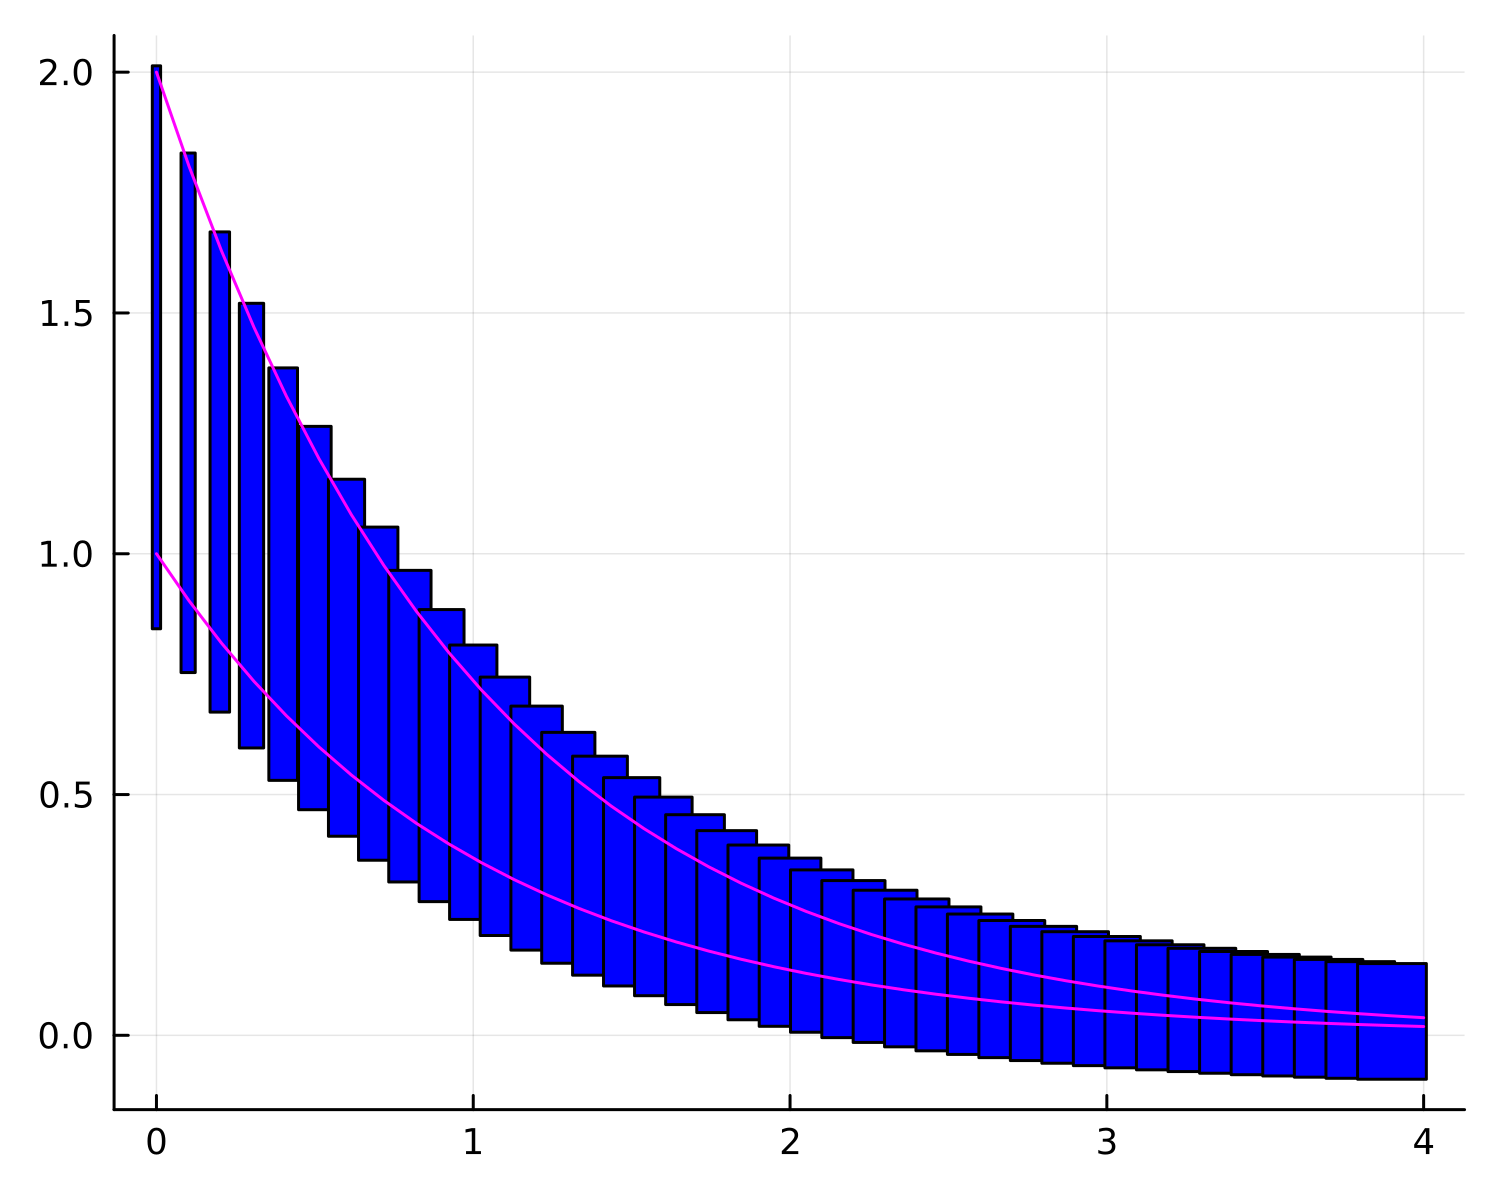

In [26]:
# Test
tΔ = 0.1


T = 4
N = floor(Int, T/tΔ )
μ = 0.1
A = [-1. 0.; 0. -1.]#UniformScaling(-1.0)
P₁ = Zonotope([0., 1.5], [0.0 0.0; 0.0 0.5])

xs = range(0, T, length=N)


boxes, R = aprox(T, tΔ, A, P₁, μ)
plotApprox(boxes, T, N)

plot!(xs, 1.0 * exp.(-xs), vars=(0, 1), c=:magenta, lab="")
plot!(xs, 2.0 * exp.(-xs), vars=(0, 1), c=:magenta, lab="")

In [51]:
# Cos wave
tΔ = 0.1
μ = 0.01

A = [cos(tΔ) sin(tΔ); -sin(tΔ) cos(tΔ)]
P₁ = Zonotope([0., 0.0], [0.0 0.0; 0.0 1])

T = 0.5

boxes, R = aprox(T, tΔ, A, P₁, μ)

N = floor(Int, T/tΔ)


5

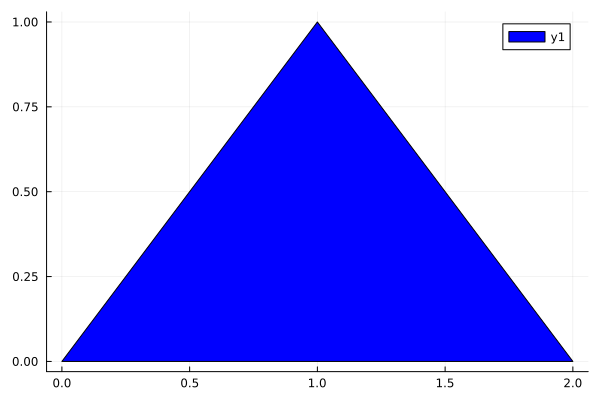

In [52]:
# Temp workplace, figuring out shapes https://docs.juliaplots.org/dev/input_data/#Shapes


someShape = Shape([(0,0), (1,1), (2,0)])

plot(someShape, c=:blue)



 Min/Max at time 0.1 :
Min -> -1.1107338406690113; Max -> 1.1107338406690113

 Min/Max at time 0.2 :
Min -> -1.2278743592860681; Max -> 1.2278743592860681

 Min/Max at time 0.30000000000000004 :
Min -> -1.3571344649136825; Max -> 1.3571344649136825

 Min/Max at time 0.4 :
Min -> -1.4997536862416203; Max -> 1.4997536862416203

 Min/Max at time 0.5 :
Min -> -1.6570967872010038; Max -> 1.6570967872010038


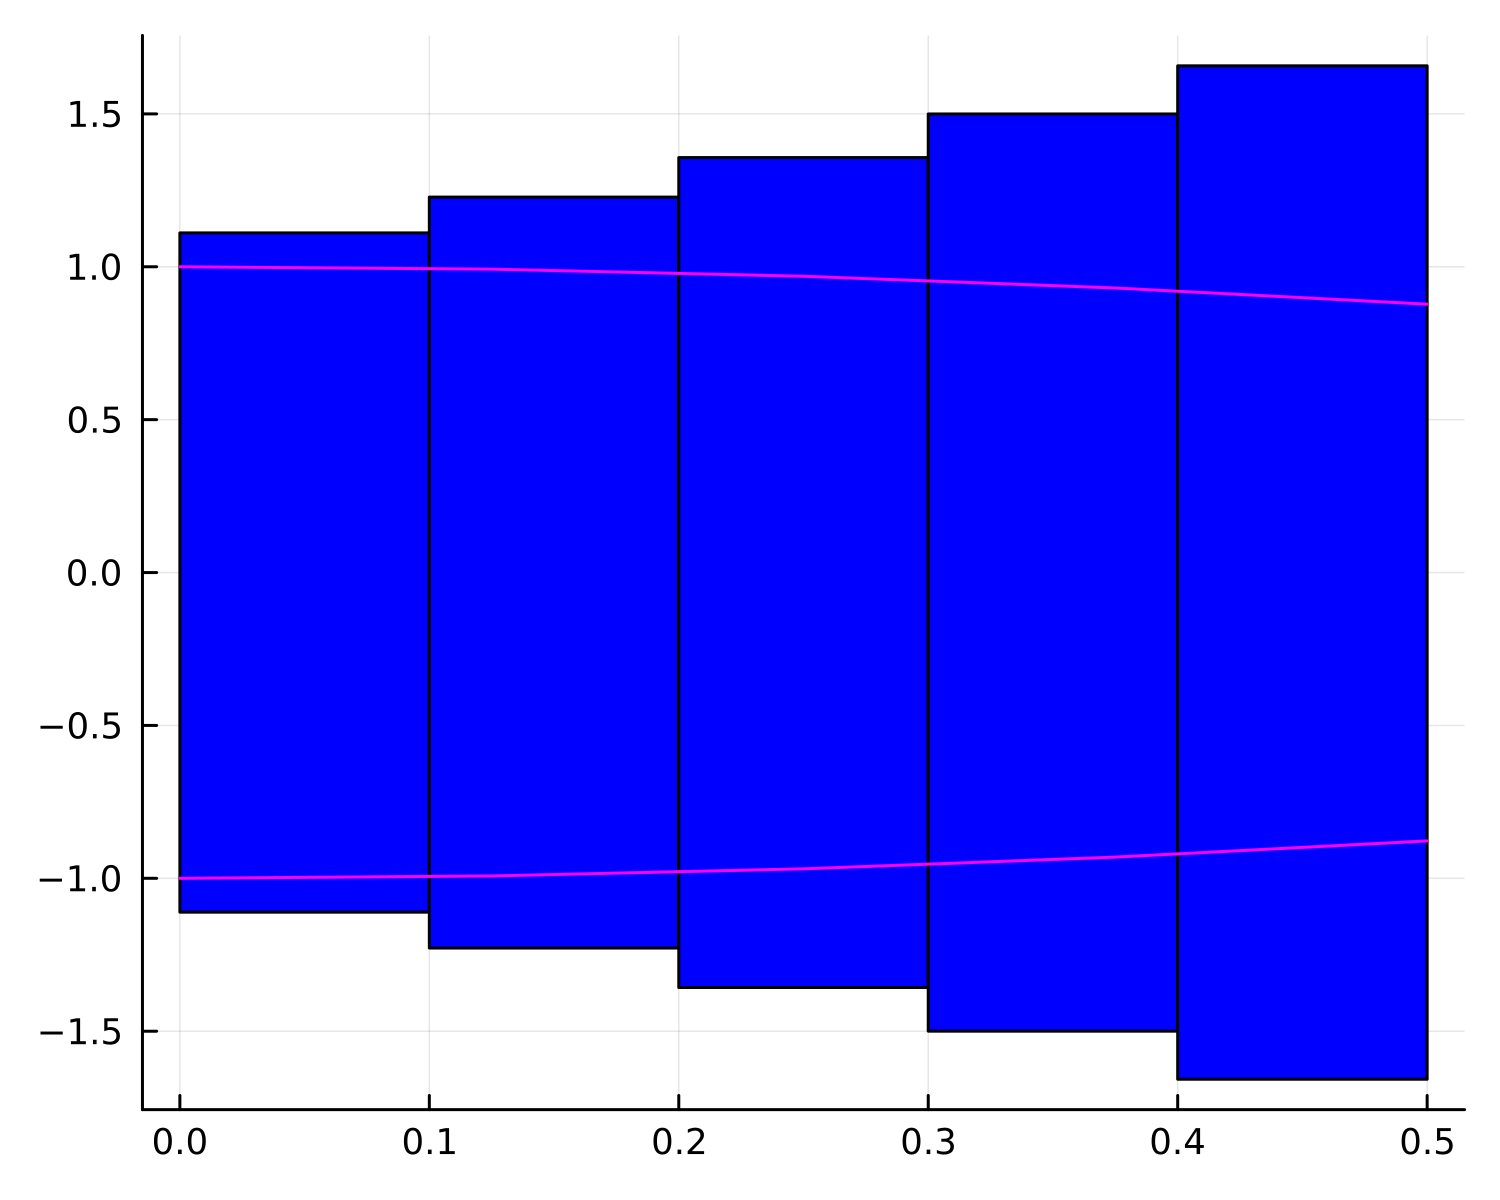

In [ ]:
# Unique plot

function rectangleFromHBox2(corners, currentTime, tΔ)
    values = getindex.(corners, 2)
    #ys = getindex.(corners, 2)

    maxVal = maximum(values)
    minVal = minimum(values)

    xs = [currentTime - tΔ, currentTime]
    ys = [maxVal, minVal]


    # Bad code, fix with more Julia experience
    shape = Shape([(xs[2], ys[2]), (xs[1], ys[2]), (xs[1], ys[1]), (xs[2], ys[1])])

    println("\n Min/Max at time $currentTime :")
    println("Min -> $minVal; Max -> $maxVal")

    return shape
end

xs = range(0, T, length=N)
maxes = []
mines = []
box = []

plot(size=(500,400), dpi=300, thickness_scaling=1)

for i in 1:(N)
    approxBox = box_approximation(boxes[i])
    corners = vertices_list(boxes[i])
    plot!(rectangleFromHBox2(corners, i*tΔ, tΔ), c=:blue,lab="")
    push!(maxes, norm(approxBox, Inf))
    push!(mines, low(approxBox, 2))
end



plot!(xs, cos.(xs), vars=(0, 1), c=:magenta, lab="")
plot!(xs, -cos.(xs), vars=(0, 1), c=:magenta, lab="")

In [ ]:
#Unique plot


# function rectangleFromHBox(corners, offset)
#     Shape((getindex.(corners, 1)).+(offset*tΔ), getindex.(corners, 2))
# end

# function plotApprox(boxes, T, N)
#     xs = range(0, T, length=N)
#     maxes = []
#     mines = []
#     box = []

#     plot(size=(500,400), dpi=300, thickness_scaling=1)

#     for i in 1:(N)
#         approxBox = box_approximation(boxes[i])
#         corners = vertices_list(boxes[i])
#         plot!(rectangleFromHBox(corners, i - 1), c=:blue,lab="")
#         push!(maxes, norm(approxBox, Inf))
#         push!(mines, low(approxBox, 2))
#     end
# end


In [15]:
# Cos wave proof of concept
μ = 0.01
tΔ = 0.2         
T = 3.0         

A = [cos(tΔ)  sin(tΔ);
    -sin(tΔ)  cos(tΔ)]

vector = [0.0  1.0] 

println("Initial: ", vector)

N = floor(Int, T / tΔ)
println("Steps: ", N)

R = vector

println("---")
for i in 1:N
    R = R * A
    println("Step $i → ", R)
end
println("---")

val = cos(T)

println("Corresponding time val: $val")

Initial: [0.0 1.0]
Steps: 15
---
Step 1 → [-0.19866933079506122 0.9800665778412416]
Step 2 → [-0.38941834230865047 0.9210609940028851]
Step 3 → [-0.5646424733950353 0.8253356149096783]
Step 4 → [-0.7173560908995227 0.6967067093471655]
Step 5 → [-0.8414709848078965 0.5403023058681398]
Step 6 → [-0.9320390859672264 0.3623577544766736]
Step 7 → [-0.9854497299884603 0.16996714290024095]
Step 8 → [-0.9995736030415052 -0.029199522301288718]
Step 9 → [-0.9738476308781953 -0.22720209469308705]
Step 10 → [-0.9092974268256817 -0.4161468365471424]
Step 11 → [-0.8084964038195902 -0.5885011172553457]
Step 12 → [-0.6754631805511508 -0.7373937155412456]
Step 13 → [-0.515501371821464 -0.8568887533689473]
Step 14 → [-0.3349881501559047 -0.9422223406686582]
Step 15 → [-0.14112000805986702 -0.9899924966004454]
---
Corresponding time val: -0.9899924966004454
